# Reinforcement Learning and Research on Novel AI Topic

## Task 1 - Reinforcement Learning

We will proceed to implement Policy Iteration for a 4x4 grid world environment.

MDP variables:
- state space: Every cell in the grid is a state, represented by (x,y) coordinates. One cell is the Start and one is the Goal. There will be Traps (Terminal states with negative rewards).
- action space: The agent can move in four directions {Up, Down, Left, Right}.
- reward structure: We give the agent +10 for reaching the goal, -10 for falling into a trap, and -0.1 for the step penalty for every normal move. This will encourage the agent to find the shortest path to the goal.
- discount factor: We have a discount factor of 0.9. This encourages the agent to consider immediate rewards more valuable.


In [2]:
import numpy as np

# MDP environment
GRID_SIZE = 4
GOAL_STATE = (3, 3)
TRAP_STATE = (2, 2)

ACTIONS = {
    0: (-1, 0),  # Up
    1: (1, 0),   # Down
    2: (0, -1),  # Left
    3: (0, 1)    # Right
}
ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

GAMMA = 0.9  # Discount factor
STEP_PENALTY = -0.1
GOAL_REWARD = 10.0
TRAP_PENALTY = -10.0

def get_next_state_and_reward(state, action_idx):
    """Returns the next state and reward given a current state and action."""
    if state == GOAL_STATE or state == TRAP_STATE:
        return state, 0.0  # Terminal states have no future rewards

    # Calculate new position
    move = ACTIONS[action_idx]
    next_r = max(0, min(GRID_SIZE - 1, state[0] + move[0]))
    next_c = max(0, min(GRID_SIZE - 1, state[1] + move[1]))
    next_state = (next_r, next_c)

    # Determine reward
    if next_state == GOAL_STATE:
        reward = GOAL_REWARD
    elif next_state == TRAP_STATE:
        reward = TRAP_PENALTY
    else:
        reward = STEP_PENALTY

    return next_state, reward

# Policy Iteration
def policy_evaluation(policy, V, theta=1e-4):
    """Evaluates the current policy to find the state values."""
    while True:
        delta = 0
        new_V = np.copy(V)
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                state = (r, c)
                if state == GOAL_STATE or state == TRAP_STATE:
                    continue

                action = policy[r, c]
                next_state, reward = get_next_state_and_reward(state, action)

                # Bellman Expectation Equation (Deterministic)
                new_V[r, c] = reward + GAMMA * V[next_state[0], next_state[1]]

                delta = max(delta, abs(new_V[r, c] - V[r, c]))

        V = new_V
        if delta < theta:
            break
    return V

def policy_improvement(V, policy):
    """Improves the policy by acting greedily with respect to the value function."""
    policy_stable = True
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == GOAL_STATE or state == TRAP_STATE:
                continue

            old_action = policy[r, c]

            # Find the best action by looking one step ahead
            action_values = []
            for a in range(4):
                next_state, reward = get_next_state_and_reward(state, a)
                value = reward + GAMMA * V[next_state[0], next_state[1]]
                action_values.append(value)

            best_action = np.argmax(action_values)
            policy[r, c] = best_action

            if old_action != best_action:
                policy_stable = False

    return policy, policy_stable

# display
def print_values(V):
    print("Value Function:")
    for r in range(GRID_SIZE):
        row_str = " | ".join([f"{V[r,c]:6.2f}" for c in range(GRID_SIZE)])
        print(row_str)
    print("-" * 35)

def print_policy(policy):
    print("Final Policy:")
    for r in range(GRID_SIZE):
        row_str = " | ".join([ACTION_SYMBOLS[policy[r,c]] if (r,c) != GOAL_STATE and (r,c) != TRAP_STATE else (" G " if (r,c) == GOAL_STATE else " X ") for c in range(GRID_SIZE)])
        print(row_str)
    print("-" * 35)

# Main Loop
# Initialize Value function (zeros) and Policy
V = np.zeros((GRID_SIZE, GRID_SIZE))
policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

iteration = 1
while True:
    print(f"--- Iteration {iteration} ---")
    V = policy_evaluation(policy, V)
    policy, policy_stable = policy_improvement(V, policy)

    if policy_stable:
        print("Policy has converged!\n")
        break
    iteration += 1

# Show final results
print_values(V)
print_policy(policy)

# Varying variable (discount factor)
print("Varying discount factor: changing from 0.9 to 0.1")
print("-"*35)

# Main Loop
# Initialize Value function (zeros) and Policy
GAMMA = 0.1
V = np.zeros((GRID_SIZE, GRID_SIZE))
policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

iteration = 1
while True:
    print(f"--- Iteration {iteration} ---")
    V = policy_evaluation(policy, V)
    policy, policy_stable = policy_improvement(V, policy)

    if policy_stable:
        print("Policy has converged!\n")
        break
    iteration += 1

# Show final results
print_values(V)
print_policy(policy)


--- Iteration 1 ---
--- Iteration 2 ---
--- Iteration 3 ---
--- Iteration 4 ---
--- Iteration 5 ---
--- Iteration 6 ---
--- Iteration 7 ---
Policy has converged!

Value Function:
  5.50 |   6.22 |   7.02 |   7.91
  6.22 |   7.02 |   7.91 |   8.90
  7.02 |   7.91 |   0.00 |  10.00
  7.91 |   8.90 |  10.00 |   0.00
-----------------------------------
Final Policy:
↓ | ↓ | ↓ | ↓
↓ | ↓ | → | ↓
↓ | ↓ |  X  | ↓
→ | → | → |  G 
-----------------------------------
Varying discount factor: changing from 0.9 to 0.1
-----------------------------------
--- Iteration 1 ---
--- Iteration 2 ---
--- Iteration 3 ---
--- Iteration 4 ---
--- Iteration 5 ---
--- Iteration 6 ---
--- Iteration 7 ---
Policy has converged!

Value Function:
 -0.11 |  -0.11 |  -0.10 |  -0.01
 -0.11 |  -0.10 |  -0.01 |   0.90
 -0.10 |  -0.01 |   0.00 |  10.00
 -0.01 |   0.90 |  10.00 |   0.00
-----------------------------------
Final Policy:
↓ | ↓ | ↓ | ↓
↓ | ↓ | → | ↓
↓ | ↓ |  X  | ↓
→ | → | → |  G 
----------------------------

This grid world environment qualifies as an MDP because it follows the Markov Property. The transitions to the next state and the rewards depend solely on the curretn state and the chosen action. The history does not influence future outcomes.

Looking at the baseline results, we see that the final policy successfully navigates to the Goal while avoiding the Trap. We observe that the agent starting at the top left is directed downwards where it eventually moves rightwards toward the goal. The closer the state is to the goal, their values in the value funciton increases.

Notice that when we change the discount factor to a low value, the values in the value function changes drastically but the final policy surprisingly didn't change. The value function changed because now future rewards are discounted heavily so the distant +10 reward for reaching the goal gets countered by the step penalities. For the policy, it seems that despite this, the relative values between neighboring states stayed the same, so the policy improvement step was able to select the exact same optimal directions.

## Task 2 - Mini Research Task

For the topic, we will research diffusion models.

We look into two sources: the foundational paper on diffusion models and a technical blog discussing these models.

### Problem, Core Idea, and Main Architecture

Diffusion models are proposed as a new way of generating high-quality samples such as images. It seeks to provide a stable, mathematically grounded training process that unlike GANs, are stable and easy to train.

The core idea behind diffusion models is training the model by slowly adding noise to data and learning to reverse it in order to construct desired data samples from noise. First we go through a forward diffusion process where we add small amounts of Gaussian noise to the given sample over many steps, producing noisy samples. This causes the sample to slowly lose its distinguishable features. Next comes the reverse diffusion process where we can recreate the true sample from a noisy input. This is done by training a neural network. It slowly removes noise step by step to turn the noisy image back into a clear image.

The architecture for diffusion models is commonly a U-Net. The U-Net involves downsampling steps where we double the feature channels and shrink the image, followed by upsampling steps where we halve the number of feature channels. There are also shortcut connects that provide essential high-resolution features to the upsampling process. Ultimately we feed the U-Net a noisy image and the current timestep and ask it to predict the noise added and we have a loss funciton that finds the MSE between the actual added noise and the predicted noise.

### Hands-On Component

We will run the diffusers from HuggingFace and compare different numbers of denoising steps. We observe that at low numbers of steps, the image generated is more distorted and messy. On future steps, we see that the model has enough steps to refine the details, resulting in crisp and highly detailed images.

### Limitations
- One limitation is the inference speed. Because of the long Markov chains, the reversal process requires passing the noisy image through the U-Net architecture many times, resulting in much slower inference speed compared to GANs and VAEs.
- Another limitation is controllability. We can give the model text prompts, but it is difficult to give it more precise constraints, like where a person should stand.

### Extension

One potential extension could be a follow-up experiment of integrating ControlNet, allowing us to provide edge maps to spatially guide the diffusion model, therefore solving the controllability limitation.

### Sources
- Ho, J., Jain, A., & Abbeel, P. (2020). Denoising diffusion probabilistic models. arXiv. https://doi.org/10.48550/arXiv.2006.11239
- Weng, L. (2021, July 11). What are diffusion models? Lil’Log. https://lilianweng.github.io/posts/2021-07-11-diffusion-models/


In [4]:
import os
os.environ["DISABLE_WIDGETS"] = "1"

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  0%|          | 0/5 [00:00<?, ?it/s]

Generating with 15 steps...


  0%|          | 0/15 [00:00<?, ?it/s]

Generating with 50 steps...


  0%|          | 0/50 [00:00<?, ?it/s]

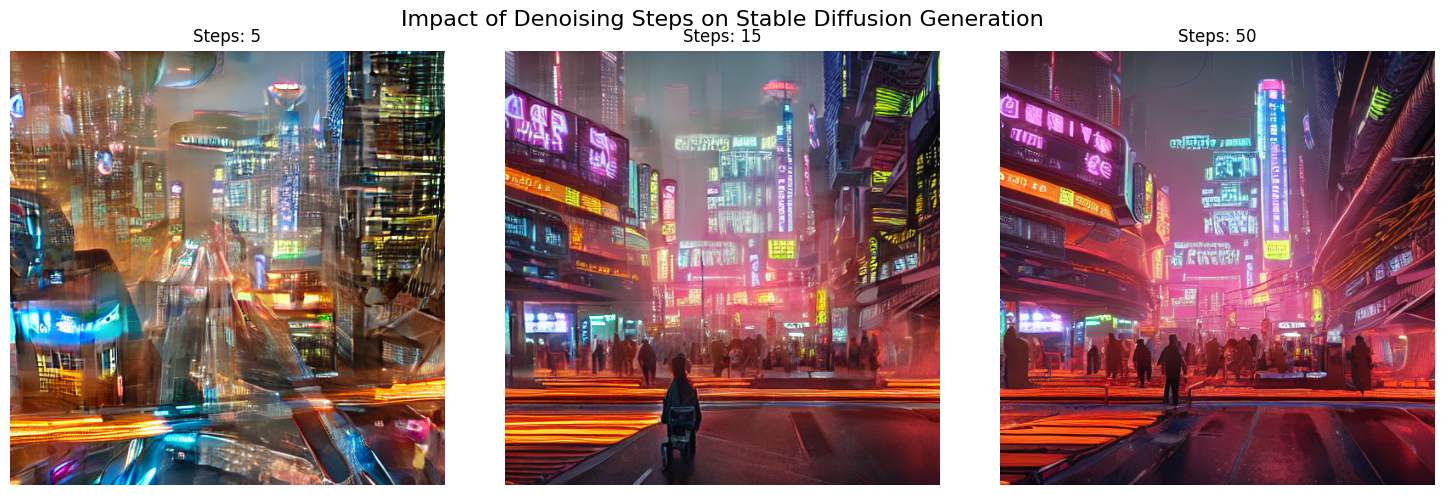

In [5]:
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

# Load the pre-trained Stable Diffusion pipeline
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

# Define our experimental variables
prompt = "A highly detailed, neon-lit futuristic sci-fi city market, cyberpunk, 8k resolution"
step_counts = [5, 15, 50]
images = []
seed = 42

# Generate Images
print(f"Generating images for prompt: '{prompt}'")
for steps in step_counts:
    print(f"Generating with {steps} steps...")
    generator = torch.Generator("cuda").manual_seed(seed)

    # Run the pipeline
    image = pipe(
        prompt,
        num_inference_steps=steps,
        generator=generator
    ).images[0]

    images.append(image)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Impact of Denoising Steps on Stable Diffusion Generation", fontsize=16)

for i, (img, steps) in enumerate(zip(images, step_counts)):
    axes[i].imshow(img)
    axes[i].set_title(f"Steps: {steps}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()